In [ ]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q gdown geopandas shapely rasterio folium matplotlib seaborn
else:
    print("Menjalankan secara lokal")

In [ ]:
import os, time
import zipfile
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import pandas as pd
from folium.plugins import MarkerCluster
import rasterio
import numpy as np

# 1w67tSo9KcnSotoj4VCR2tJKGCRXUp_NN
# 13vFEkQedUeLzNHRcU4bH9gMd56ZALiPL

file_id = "1Hi05v9z0o397NGZer0YxcEwISpNzrne9"
zip_file = "POSEIDON_WPP711_complete.zip"

if not os.path.exists(zip_file):
    gdown.download(id=file_id, output=zip_file, quiet=False)

if os.path.exists(zip_file):
    print("Mengekstrak")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Ekstraksi selesai")
else:
    print("Gagal")

Downloading...
From (original): https://drive.google.com/uc?id=1Hi05v9z0o397NGZer0YxcEwISpNzrne9
From (redirected): https://drive.google.com/uc?id=1Hi05v9z0o397NGZer0YxcEwISpNzrne9&confirm=t&uuid=17dca57d-9812-429d-b2bb-aa5b82f8a1d8
To: /content/POSEIDON_WPP711_complete.zip
100%|██████████| 29.1M/29.1M [00:01<00:00, 28.3MB/s]


Mengekstrak
Ekstraksi selesai


In [ ]:
main_dataset_filename = "POSEIDON_WPP711_complete.csv"

if 'google.colab' in sys.modules:
    from google.colab import files

    if not os.path.exists(main_dataset_filename):
        print(f"Upload '{main_dataset_filename}'...")
        uploaded = files.upload()

        if main_dataset_filename not in uploaded:
            main_dataset_filename = list(uploaded.keys())[0]
    else:
        print(f"File '{main_dataset_filename}' sudah ada di lokal, skip upload")
else:
    print("Mode lokal, pastikan file sudah berada di working directory")

print("File ditemukan:", os.path.exists(main_dataset_filename))
if os.path.exists(main_dataset_filename):
    print("Ukuran berkas:", os.path.getsize(main_dataset_filename), "bytes")

File 'POSEIDON_WPP711_complete.csv' sudah ada di lokal, skip upload
File ditemukan: True
Ukuran berkas: 51628548 bytes


## DIMENSI B

In [ ]:
seizures_path = "labels/iuu_seizure_records_2023_2025.csv"
ports_path = "ports/fishing_ports_wpp711.csv"
mpa_path = "shapefiles/mpa_wpp711.shp"
eez_path = "shapefiles/zee_wpp711.shp"
wpp_path = "shapefiles/wpp_wpp711.shp"
bathymetry_path = "bathymetry/gebco_2024_n7.74_s-4.16_w102.9_e111.05_geotiff.tif"

paths = [seizures_path, ports_path, mpa_path, eez_path, wpp_path, bathymetry_path]
for p in paths:
    print(f"File '{p}': {'Ditemukan' if os.path.exists(p) else 'TIDAK DITEMUKAN'}")

File 'labels/iuu_seizure_records_2023_2025.csv': Ditemukan
File 'ports/fishing_ports_wpp711.csv': Ditemukan
File 'shapefiles/mpa_wpp711.shp': Ditemukan
File 'shapefiles/zee_wpp711.shp': Ditemukan
File 'shapefiles/wpp_wpp711.shp': Ditemukan
File 'bathymetry/gebco_2024_n7.74_s-4.16_w102.9_e111.05_geotiff.tif': Ditemukan


In [ ]:
df_seizures = pd.read_csv(seizures_path)
df_seizures['date'] = pd.to_datetime(df_seizures['date'])

print(f"Total data penangkapan kapal: {len(df_seizures)} baris")
print("\n5 Baris Pertama Data Penangkapan")
display(df_seizures.head())
df_seizures.to_csv('POSEIDON_WPP711_seizures.csv', index=False)
print("\nFile 'POSEIDON_WPP711_seizures.csv' saved.")

Total data penangkapan kapal: 61 baris

5 Baris Pertama Data Penangkapan


,date,lat,lon,vessel_flag,vessel_type,gt,violation_note,source_url
0,2023-03-20,-3.442167,106.528817,Indonesia,Jaring Tarik Berkantong,94.0,Melakukan penangkapan ikan tidak sesuai dengan...,PSDKP Official Data
1,2023-03-20,-3.453417,106.549083,Indonesia,Jaring Tarik Berkantong,112.0,Melakukan penangkapan ikan tidak sesuai dengan...,PSDKP Official Data
2,2023-03-22,2.694850,105.023117,Indonesia,Jala Jatuh Berkapal,29.0,Melakukan penangkapan ikan tanpa dolengkapi k...,PSDKP Official Data
3,2023-03-22,2.730900,104.990767,Indonesia,Jala Jatuh Berkapal,29.0,Melakukan penangkapan ikan tanpa dolengkapi k...,PSDKP Official Data
4,2023-03-27,2.885533,104.881383,Vietnam,Trawl,89.0,Melakukan penangkapan ikan tanpa dilengkapi iz...,PSDKP Official Data



File 'POSEIDON_WPP711_seizures.csv' saved.


/tmp/ipykernel_2765/4017238186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_seizures, y='vessel_flag', order=df_seizures['vessel_flag'].value_counts().index, palette='viridis')


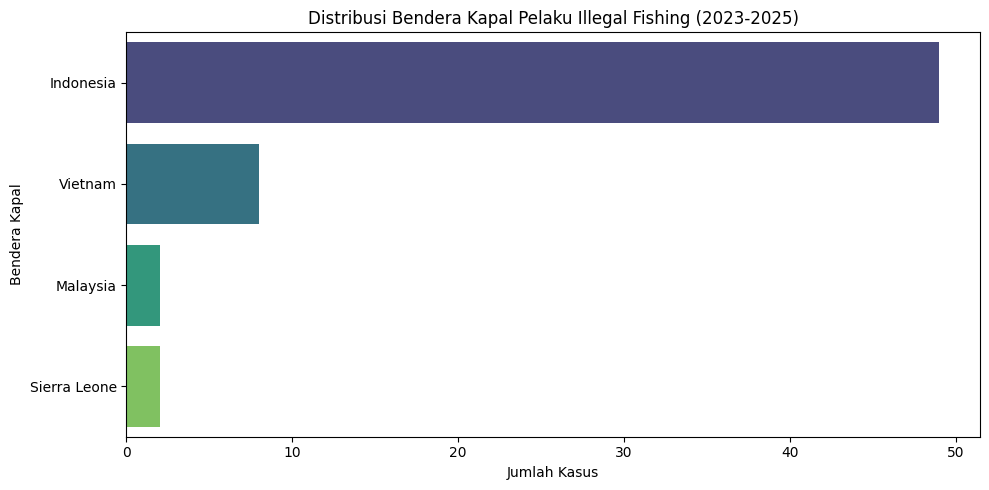

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_seizures, y='vessel_flag', order=df_seizures['vessel_flag'].value_counts().index, palette='viridis')
plt.title('Distribusi Bendera Kapal Pelaku Illegal Fishing (2023-2025)')
plt.xlabel('Jumlah Kasus')
plt.ylabel('Bendera Kapal')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2765/4177106415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_seizures, y='vessel_type', order=df_seizures['vessel_type'].value_counts().index, palette='magma')


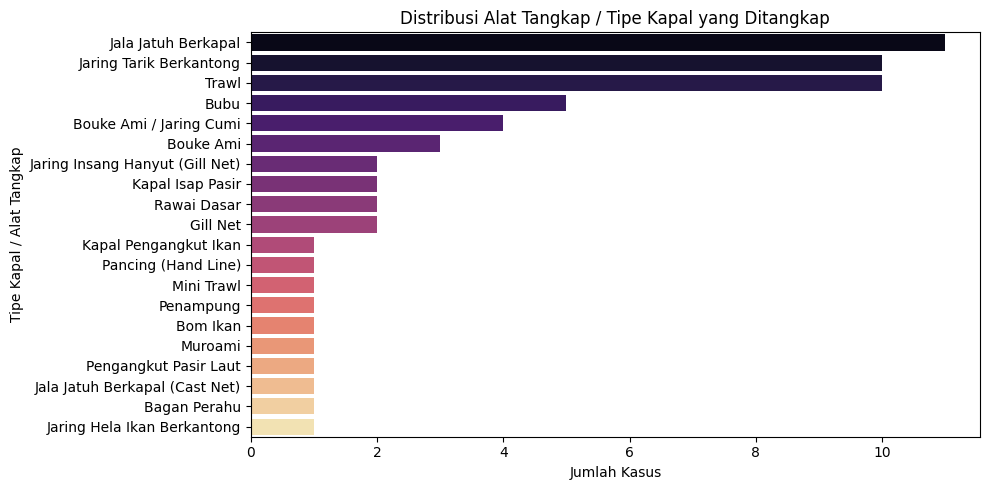

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_seizures, y='vessel_type', order=df_seizures['vessel_type'].value_counts().index, palette='magma')
plt.title('Distribusi Alat Tangkap / Tipe Kapal yang Ditangkap')
plt.xlabel('Jumlah Kasus')
plt.ylabel('Tipe Kapal / Alat Tangkap')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2765/3026394843.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_seizures, x='year', palette='Blues')


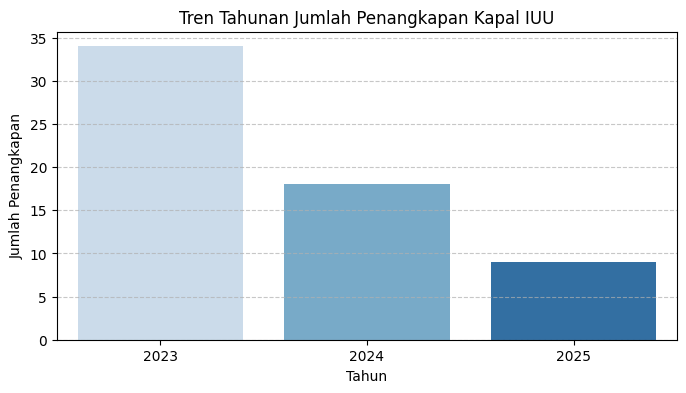

In [ ]:
df_seizures['year'] = df_seizures['date'].dt.year
plt.figure(figsize=(8, 4))
sns.countplot(data=df_seizures, x='year', palette='Blues')
plt.title('Tren Tahunan Jumlah Penangkapan Kapal IUU')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Penangkapan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[2.0, 109.0], zoom_start=6, tiles='CartoDB Positron')

df_ports = pd.read_csv(ports_path)

seizure_cluster = MarkerCluster(name="Titik Penangkapan Kapal IUU").add_to(m)
for idx, row in df_seizures.iterrows():
    d_str = row['date']
    if not isinstance(d_str, str):
        d_str = d_str.strftime('%Y-%m-%d')
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"<b>Bendera:</b> {row['vessel_flag']}<br><b>Alat Tangkap:</b> {row['vessel_type']}<br><b>Tanggal:</b> {d_str}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(seizure_cluster)

port_group = folium.FeatureGroup(name="Pelabuhan Perikanan Terdekat").add_to(m)
for idx, row in df_ports.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"<b>Nama:</b> {row['port_name']}<br><b>Tipe:</b> {row['type']}<br><b>Wilayah:</b> {row.get('region', 'N/A')}",
        icon=folium.Icon(color='blue', icon='anchor', prefix='fa')
    ).add_to(port_group)

folium.LayerControl().add_to(m)
m

Raster Bounds: BoundingBox(left=102.9, bottom=-4.158333333333333, right=111.04999999999998, top=7.741666666666662)
Raster CRS: EPSG:4326
Raster Size: 1956x2856

Berhasil mengekstrak data kedalaman untuk 56 titik penangkapan di area Natuna.


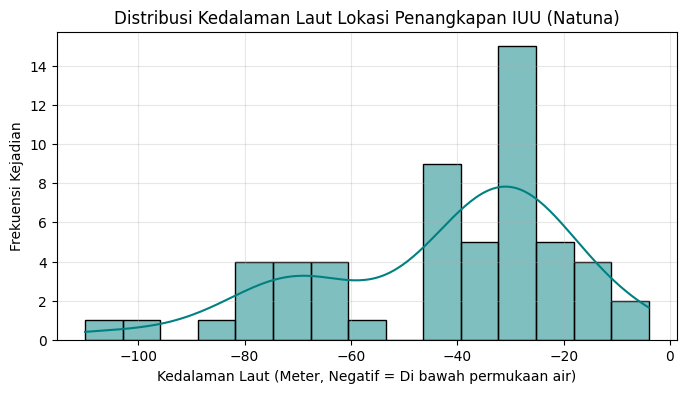

In [ ]:
depths = []
valid_points_count = 0

with rasterio.open(bathymetry_path) as src:
    print(f"Raster Bounds: {src.bounds}")
    print(f"Raster CRS: {src.crs}")
    print(f"Raster Size: {src.width}x{src.height}")

    for idx, row in df_seizures.iterrows():
        lat, lon = row['lat'], row['lon']
        if (src.bounds.left <= lon <= src.bounds.right) and (src.bounds.bottom <= lat <= src.bounds.top):
            row_col = src.index(lon, lat)
            depth_val = src.read(1)[row_col]
            depths.append(depth_val)
            valid_points_count += 1
        else:
            depths.append(None)

df_seizures['ocean_depth_m'] = depths
print(f"\nBerhasil mengekstrak data kedalaman untuk {valid_points_count} titik penangkapan di area Natuna.")

df_natuna_seizures = df_seizures.dropna(subset=['ocean_depth_m'])
if len(df_natuna_seizures) > 0:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_natuna_seizures['ocean_depth_m'], bins=15, kde=True, color='teal')
    plt.title('Distribusi Kedalaman Laut Lokasi Penangkapan IUU (Natuna)')
    plt.xlabel('Kedalaman Laut (Meter, Negatif = Di bawah permukaan air)')
    plt.ylabel('Frekuensi Kejadian')
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
import geopandas as gpd
import re
import math
import time
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon, MultiPolygon
from scipy.spatial import cKDTree

def fill_holes(geom):
    if geom.geom_type == 'Polygon':
        return Polygon(geom.exterior)
    elif geom.geom_type == 'MultiPolygon':
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    return geom

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1))*math.cos(math.radians(lat2))*math.sin(dlon/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def haversine_km_vectorized(lat1, lon1, lat2_arr, lon2_arr):
    R = 6371.0
    lat1_r = np.radians(lat1)
    lon1_r = np.radians(lon1)
    lat2_r = np.radians(lat2_arr)
    lon2_r = np.radians(lon2_arr)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat/2)**2 + np.cos(lat1_r)*np.cos(lat2_r)*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def main():
    csv_path = 'POSEIDON_WPP711_complete.csv'

    print("Memuat data spasial WPP 711")
    t0 = time.time()
    df_ports = pd.read_csv(ports_path)
    df_seizures = pd.read_csv(seizures_path)

    df_seizures['year'] = pd.to_datetime(df_seizures['date']).dt.year
    df_seizures_ref = df_seizures[df_seizures['year'] <= 2024].copy()
    print(f"[Seizure Reference] Menggunakan {len(df_seizures_ref)} titik referensi historis (2023-2024) dari total {len(df_seizures)} titik.")

    mpa = gpd.read_file(mpa_path).to_crs('EPSG:4326')
    eez = gpd.read_file(eez_path).to_crs('EPSG:4326')
    eez['geometry'] = eez.geometry.apply(fill_holes)
    print(f"[Selesai] Memuat file spasial dalam {time.time() - t0:.2f} detik.")

    ports_lat = df_ports.lat.values
    ports_lon = df_ports.lon.values
    seiz_lat = df_seizures_ref.lat.values
    seiz_lon = df_seizures_ref.lon.values

    print("\nMelakukan proyeksi peta ke EPSG:3857")
    t0 = time.time()
    mpa_proj = mpa.to_crs('EPSG:3857')
    eez_proj = eez.to_crs('EPSG:3857')
    mpa_centroids = mpa_proj.geometry.centroid
    mpa_centroid_coords = np.array([(c.x, c.y) for c in mpa_centroids])
    mpa_tree = cKDTree(mpa_centroid_coords)
    print(f"[Selesai] Proyeksi selesai dalam {time.time() - t0:.2f} detik.")

    print("\nMemproses deteksi kapal dalam chunk (10.000 baris per batch)")
    chunk_size = 10000
    chunk_list = []
    chunk_idx = 1

    total_rows = sum(1 for _ in open(csv_path, encoding='utf-8')) - 1
    total_batches = math.ceil(total_rows / chunk_size)
    print(f"Total data: {total_rows} baris, {total_batches} batch")

    for chunk in pd.read_csv(csv_path, chunksize=chunk_size, low_memory=False):
        t_chunk = time.time()
        print(f"-> Memproses batch {chunk_idx}/{total_batches} ({len(chunk)} baris)")

        gdf_points = gpd.GeoDataFrame(
            chunk,
            geometry=gpd.points_from_xy(chunk.lon, chunk.lat),
            crs='EPSG:4326'
        )
        gdf_points_proj = gdf_points.to_crs('EPSG:3857')

        dist_mpa_list = []
        inside_mpa_list = []
        dist_eez_list = []
        dist_port_list = []
        dist_seizure_list = []

        for idx, row in gdf_points_proj.iterrows():
            lat, lon = float(row['lat']), float(row['lon'])
            point_geom = row['geometry']
            point_xy = np.array([point_geom.x, point_geom.y])

            _, closest_indices = mpa_tree.query(point_xy, k=min(5, len(mpa_centroids)))
            if isinstance(closest_indices, np.integer):
                closest_indices = [closest_indices]
            candidates = mpa_proj.iloc[closest_indices]

            distances_mpa_m = candidates.boundary.distance(point_geom)
            min_dist_mpa_m = distances_mpa_m.min()
            inside_mpa = int(candidates.contains(point_geom).any())

            d_mpa = min_dist_mpa_m / 1000.0
            if inside_mpa:
                d_mpa = -d_mpa

            dist_eez_m = eez_proj.boundary.distance(point_geom).min()
            inside_eez = eez_proj.contains(point_geom).any()

            d_eez = dist_eez_m / 1000.0
            if not inside_eez:
                d_eez = -d_eez

            d_port = haversine_km_vectorized(lat, lon, ports_lat, ports_lon).min()

            dists_seiz = haversine_km_vectorized(lat, lon, seiz_lat, seiz_lon)
            dists_sorted = np.sort(dists_seiz)
            if len(dists_sorted) > 1 and dists_sorted[0] < 0.05:
                d_seiz = dists_sorted[1]
            else:
                d_seiz = dists_sorted[0]

            dist_mpa_list.append(round(d_mpa, 2))
            inside_mpa_list.append(inside_mpa)
            dist_eez_list.append(round(d_eez, 2))
            dist_port_list.append(round(d_port, 2))
            dist_seizure_list.append(round(d_seiz, 2))

        chunk['dist_to_nearest_mpa_km'] = dist_mpa_list
        chunk['inside_mpa'] = inside_mpa_list
        chunk['dist_to_eez_boundary_km'] = dist_eez_list
        chunk['dist_to_nearest_port_km'] = dist_port_list
        chunk['dist_to_nearest_seizure_km'] = dist_seizure_list

        chunk_list.append(chunk)
        elapsed = time.time() - t_chunk
        remaining = elapsed * (total_batches - chunk_idx)
        print(f"  Batch {chunk_idx} selesai dalam {elapsed:.2f} detik. (Estimasi sisa: {remaining/60:.1f} menit)")
        chunk_idx += 1

    print("\nMenggabungkan hasil batch dan menyimpan ke file CSV")
    df_final = pd.concat(chunk_list, ignore_index=True)

    if 'geometry' in df_final.columns:
        df_final = df_final.drop(columns=['geometry'])

    output_path = 'POSEIDON_WPP711_complete_enriched.csv'
    df_final.to_csv(output_path, index=False)
    print(f"[Selesai] File berhasil disimpan di: {output_path}")
    print(f"Dimensi baris akhir: {df_final.shape}")

if __name__ == '__main__':
    main()

Memuat data spasial WPP 711
[Seizure Reference] Menggunakan 52 titik referensi historis (2023-2024) dari total 61 titik.
[Selesai] Memuat file spasial dalam 0.60 detik.

Melakukan proyeksi peta ke EPSG:3857
[Selesai] Proyeksi selesai dalam 0.17 detik.

Memproses deteksi kapal dalam chunk (10.000 baris per batch)
Total data: 153523 baris, 16 batch
-> Memproses batch 1/16 (10000 baris)
  Batch 1 selesai dalam 45.20 detik. (Estimasi sisa: 11.3 menit)
-> Memproses batch 2/16 (10000 baris)
  Batch 2 selesai dalam 45.49 detik. (Estimasi sisa: 10.6 menit)
-> Memproses batch 3/16 (10000 baris)
  Batch 3 selesai dalam 49.79 detik. (Estimasi sisa: 10.8 menit)
-> Memproses batch 4/16 (10000 baris)
  Batch 4 selesai dalam 45.54 detik. (Estimasi sisa: 9.1 menit)
-> Memproses batch 5/16 (10000 baris)
  Batch 5 selesai dalam 43.91 detik. (Estimasi sisa: 8.1 menit)
-> Memproses batch 6/16 (10000 baris)
  Batch 6 selesai dalam 44.78 detik. (Estimasi sisa: 7.5 menit)
-> Memproses batch 7/16 (10000 baris

In [ ]:
df_complete = pd.read_csv('POSEIDON_WPP711_complete_enriched.csv', low_memory=False)

display(df_complete[['ais_flag_country', 'dist_to_nearest_mpa_km', 'inside_mpa',
                     'dist_to_eez_boundary_km', 'dist_to_nearest_port_km',
                     'dist_to_nearest_seizure_km']].describe())

,dist_to_nearest_mpa_km,inside_mpa,dist_to_eez_boundary_km,dist_to_nearest_port_km,dist_to_nearest_seizure_km
count,153523.000000,153523.000000,153523.000000,153523.000000,153523.000000
mean,51.682476,0.046039,61.203204,60.409722,67.798730
std,41.142584,0.209570,64.797944,42.792816,49.402248
min,-19.860000,0.000000,-35.530000,1.320000,0.060000
25%,18.790000,0.000000,8.900000,26.340000,27.810000
50%,39.510000,0.000000,37.760000,48.070000,54.770000
75%,78.160000,0.000000,97.410000,86.690000,99.550000
max,231.870000,1.000000,275.210000,271.280000,294.620000


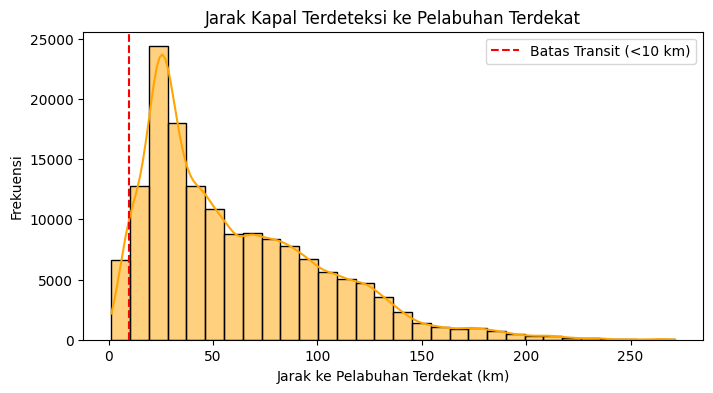

Interpretasi: Menunjukkan sebaran jarak operasional kapal terhadap pelabuhan terdekat.


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df_complete['dist_to_nearest_port_km'], bins=30, kde=True, color='orange')
plt.axvline(10, color='red', linestyle='--', label='Batas Transit (<10 km)')
plt.title('Jarak Kapal Terdeteksi ke Pelabuhan Terdekat')
plt.xlabel('Jarak ke Pelabuhan Terdekat (km)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()
print("Interpretasi: Menunjukkan sebaran jarak operasional kapal terhadap pelabuhan terdekat.")

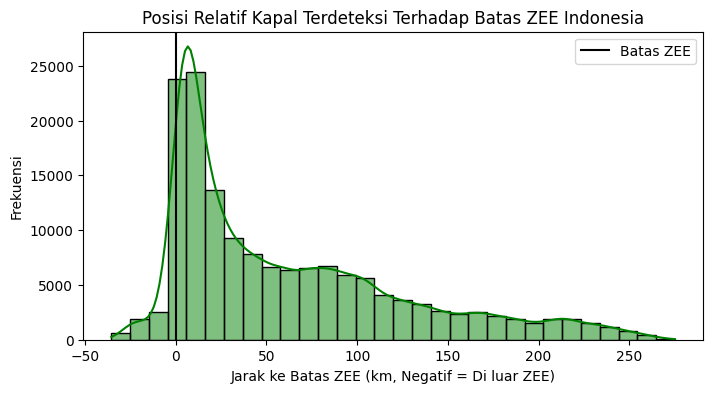

Interpretasi: Menunjukkan seberapa dekat pola pergerakan kapal dengan garis batas ZEE


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df_complete['dist_to_eez_boundary_km'], bins=30, kde=True, color='green')
plt.axvline(0, color='black', linestyle='-', label='Batas ZEE')
plt.title('Posisi Relatif Kapal Terdeteksi Terhadap Batas ZEE Indonesia')
plt.xlabel('Jarak ke Batas ZEE (km, Negatif = Di luar ZEE)')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()
print("Interpretasi: Menunjukkan seberapa dekat pola pergerakan kapal dengan garis batas ZEE")

/tmp/ipykernel_2765/1442222461.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y='ais_flag_country', order=top_countries, palette='Set2')


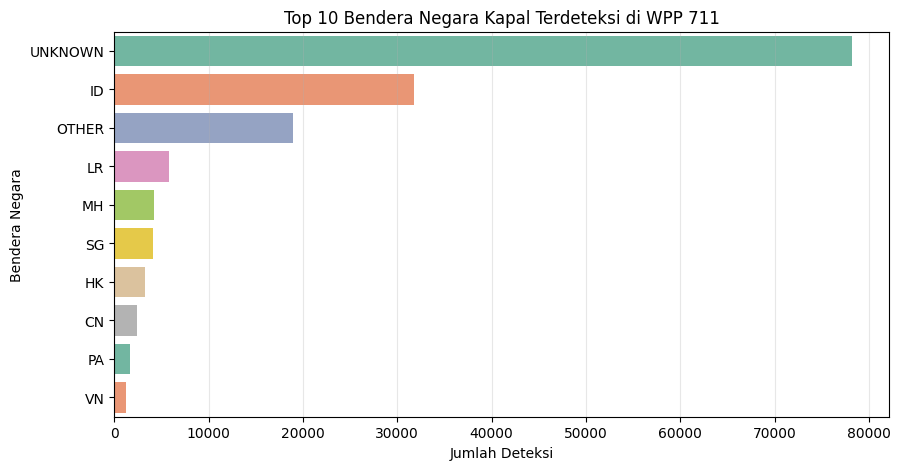

In [ ]:
plt.figure(figsize=(10, 5))
top_countries = df_complete['ais_flag_country'].value_counts().nlargest(10).index
df_filtered = df_complete[df_complete['ais_flag_country'].isin(top_countries)]

sns.countplot(data=df_filtered, y='ais_flag_country', order=top_countries, palette='Set2')
plt.title('Top 10 Bendera Negara Kapal Terdeteksi di WPP 711')
plt.xlabel('Jumlah Deteksi')
plt.ylabel('Bendera Negara')
plt.grid(axis='x', alpha=0.3)
plt.show()

/tmp/ipykernel_2765/125689862.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, y='ais_flag_country', order=top_countries, palette='Set2')


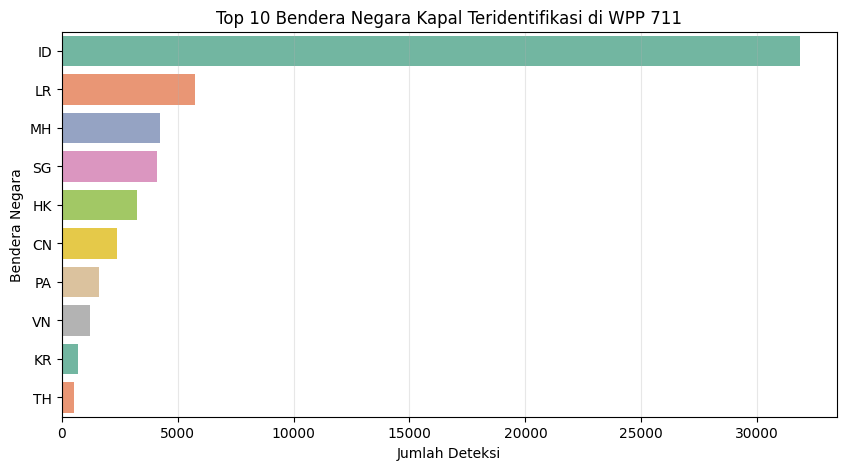

In [ ]:
plt.figure(figsize=(10, 5))

df_identified = df_complete[~df_complete['ais_flag_country'].isin(['UNKNOWN', 'OTHER', None])]

top_countries = df_identified['ais_flag_country'].value_counts().nlargest(10).index
df_filtered = df_identified[df_identified['ais_flag_country'].isin(top_countries)]

sns.countplot(data=df_filtered, y='ais_flag_country', order=top_countries, palette='Set2')
plt.title('Top 10 Bendera Negara Kapal Teridentifikasi di WPP 711')
plt.xlabel('Jumlah Deteksi')
plt.ylabel('Bendera Negara')
plt.grid(axis='x', alpha=0.3)
plt.show()

/tmp/ipykernel_2765/2457889474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_complete, x='ais_matched', palette='coolwarm')


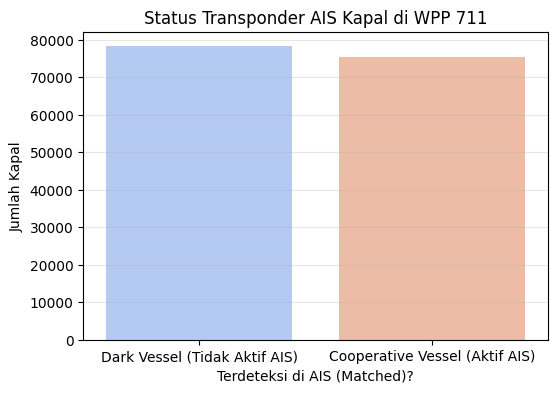

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_complete, x='ais_matched', palette='coolwarm')
plt.title('Status Transponder AIS Kapal di WPP 711')
plt.xlabel('Terdeteksi di AIS (Matched)?')
plt.ylabel('Jumlah Kapal')
plt.xticks([0, 1], ['Dark Vessel (Tidak Aktif AIS)', 'Cooperative Vessel (Aktif AIS)'])
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_2765/2278560579.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_complete, x='matched_category', palette='viridis',


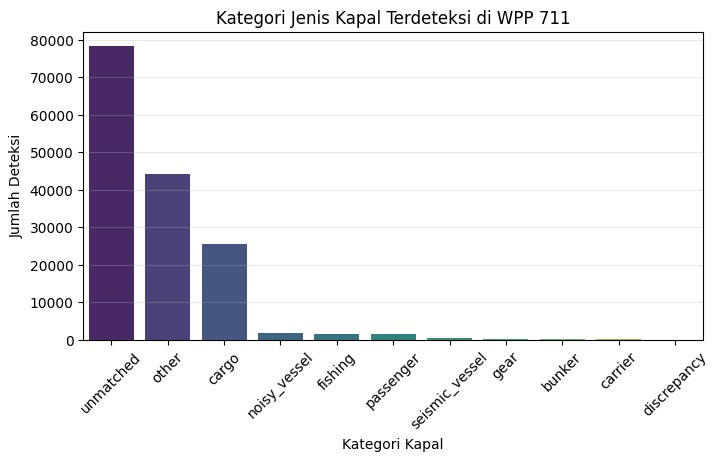

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_complete, x='matched_category', palette='viridis',
              order=df_complete['matched_category'].value_counts().index)
plt.title('Kategori Jenis Kapal Terdeteksi di WPP 711')
plt.xlabel('Kategori Kapal')
plt.ylabel('Jumlah Deteksi')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## DIMENSI A, C, D

In [ ]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

In [ ]:
import pandas as pd

df = pd.read_csv('POSEIDON_WPP711_complete_enriched.csv', low_memory=False)

before_drop = len(df)
df = df.dropna(subset=['vv_intensity_db', 'snr_db', 'background_clutter'])
after_drop = len(df)

df.to_csv('POSEIDON_WPP711_complete_enriched.csv', index=False)

print(f"Jumlah baris sebelum dihapus: {before_drop}")
print(f"Jumlah baris setelah menghapus missing value: {after_drop}")
print(f"Baris yang dibuang: {before_drop - after_drop}")

print("\nVerifikasi Akhir")
missing_check = df[['vv_intensity_db', 'vh_intensity_db', 'snr_db', 'background_clutter']].isnull().sum()
print("Jumlah Missing Value:")
print(missing_check)

if missing_check.sum() == 0:
    print("\nSTATUS: DATA BERSIH (100% CLEAN).")
else:
    print("\nSTATUS: Masih ada masalah.")

Jumlah baris sebelum dihapus: 153521
Jumlah baris setelah menghapus missing value: 153521
Baris yang dibuang: 0

Verifikasi Akhir
Jumlah Missing Value:
vv_intensity_db       0
vh_intensity_db       0
snr_db                0
background_clutter    0
dtype: int64

STATUS: DATA BERSIH (100% CLEAN).


In [ ]:
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')

print("Rentang latitude :", df['lat'].min(), "sampai", df['lat'].max())
print("Rentang longitude:", df['lon'].min(), "sampai", df['lon'].max())

wpp711_bbox_check = (
    (df['lat'].between(-4.5, 8.0)).all() and
    (df['lon'].between(102.5, 111.5)).all()
)
print("Seluruh data berada dalam bounding box WPP 711:", wpp711_bbox_check)

narrow_bbox = df[(df['lat'].between(3, 6)) & (df['lon'].between(107, 109))]
print("\nJumlah baris dalam bounding box ASLI (3-6 LU, 107-109 BT):", len(narrow_bbox))
print("Ekspektasi sesuai dokumen justifikasi: 4111 baris ->",
      "SESUAI" if len(narrow_bbox) == 4111 else "TIDAK SESUAI, perlu dicek ulang")

print("\nDistribusi matched_category (seluruh dataset, bbox ekspansi):")
print(df['matched_category'].value_counts())

n_unmatched = (df['matched_category'] == 'unmatched').sum()
n_other = len(df) - n_unmatched
print(f"\nProxy Unlabeled/dark (matched_category='unmatched') : {n_unmatched} baris")
print(f"Proxy Reliable Negative (matched_category != 'unmatched') : {n_other} baris")
print("Catatan: ini hanya proxy kasar untuk konteks PU Learning, label P/RN/U final ditentukan di tahap pelabelan terpisah.")

print("\nJumlah scene unik (Sentinel-1):", df['scene_id'].nunique())
print("Rentang tahun data:", sorted(df['year'].unique()))

Rentang latitude : -4.148059152738764 sampai 5.664842716133333
Rentang longitude: 102.95958996445144 sampai 110.58934706296138
Seluruh data berada dalam bounding box WPP 711: True

Jumlah baris dalam bounding box ASLI (3-6 LU, 107-109 BT): 4111
Ekspektasi sesuai dokumen justifikasi: 4111 baris -> SESUAI

Distribusi matched_category (seluruh dataset, bbox ekspansi):
matched_category
unmatched         78229
other             44075
cargo             25380
noisy_vessel       1669
fishing            1615
passenger          1560
seismic_vessel      395
gear                248
bunker              191
carrier             158
discrepancy           1
Name: count, dtype: int64

Proxy Unlabeled/dark (matched_category='unmatched') : 78229 baris
Proxy Reliable Negative (matched_category != 'unmatched') : 75292 baris
Catatan: ini hanya proxy kasar untuk konteks PU Learning, label P/RN/U final ditentukan di tahap pelabelan terpisah.

Jumlah scene unik (Sentinel-1): 2136
Rentang tahun data: [np.int64(2

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert(None)
df['pass_date'] = df['timestamp'].dt.floor('D')
df['grid_lat'] = np.floor(df['lat'] / 0.1).astype(int)
df['grid_lon'] = np.floor(df['lon'] / 0.1).astype(int)
df['is_dark'] = (df['matched_category'] == 'unmatched').astype(int)

df = df.sort_values('timestamp').reset_index(drop=True)

print("Contoh hasil grid (5 baris pertama):")
print(df[['lat', 'lon', 'grid_lat', 'grid_lon', 'timestamp', 'pass_date', 'is_dark']].head())

print("\nJumlah grid unik:", df.groupby(['grid_lat', 'grid_lon']).ngroups)
print("Rentang grid_lat:", df['grid_lat'].min(), "sampai", df['grid_lat'].max())
print("Rentang grid_lon:", df['grid_lon'].min(), "sampai", df['grid_lon'].max())
print("\nTotal baris is_dark = 1:", df['is_dark'].sum(), "dari", len(df), "baris")
print("Validasi is_dark vs matched_category unmatched:",
      (df['is_dark'].sum() == (df['matched_category'] == 'unmatched').sum()))

print("\nTimestamp setelah konversi sudah urut:", df['timestamp'].is_monotonic_increasing)
print("Index sudah direset 0..n-1:", list(df.index[:3]), "...", list(df.index[-3:]))

Contoh hasil grid (5 baris pertama):
        lat         lon  grid_lat  grid_lon           timestamp  pass_date  is_dark
0  2.246864  109.291632        22      1092 2023-01-01 22:23:34 2023-01-01        1
1  3.491837  109.623754        34      1096 2023-01-01 22:23:34 2023-01-01        0
2  2.203675  109.132763        22      1091 2023-01-01 22:23:34 2023-01-01        0
3  2.098810  109.531435        20      1095 2023-01-01 22:23:34 2023-01-01        1
4  3.354590  109.577119        33      1095 2023-01-01 22:23:34 2023-01-01        0

Jumlah grid unik: 4096
Rentang grid_lat: -42 sampai 56
Rentang grid_lon: 1029 sampai 1105

Total baris is_dark = 1: 78229 dari 153521 baris
Validasi is_dark vs matched_category unmatched: True

Timestamp setelah konversi sudah urut: True
Index sudah direset 0..n-1: [0, 1, 2] ... [153518, 153519, 153520]


In [ ]:
sorted_pass_dates = sorted(df['pass_date'].unique())
prev_pass_date_map = {
    d: (sorted_pass_dates[i - 1] if i > 0 else None)
    for i, d in enumerate(sorted_pass_dates)
}

print("Jumlah pass (tanggal unik) sepanjang dataset:", len(sorted_pass_dates))
print("Pass pertama :", sorted_pass_dates[0])
print("Pass terakhir:", sorted_pass_dates[-1])

gap_days = pd.Series(sorted_pass_dates).diff().dropna().dt.days
print("\nStatistik jarak antar pass (hari):")
print(gap_days.describe())

n_no_prev = sum(1 for d in df['pass_date'] if prev_pass_date_map[d] is None)
print(f"\nJumlah baris pada pass PERTAMA (tidak punya pass sebelumnya): {n_no_prev}")
print("Baris-baris ini akan otomatis bernilai 0 untuk neighbor_dark_prev dan vessel_redetection")

Jumlah pass (tanggal unik) sepanjang dataset: 570
Pass pertama : 2023-01-01 00:00:00
Pass terakhir: 2025-12-31 00:00:00

Statistik jarak antar pass (hari):
count    569.000000
mean       1.924429
std        0.992712
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        8.000000
dtype: float64

Jumlah baris pada pass PERTAMA (tidak punya pass sebelumnya): 108
Baris-baris ini akan otomatis bernilai 0 untuk neighbor_dark_prev dan vessel_redetection


In [ ]:
MOORE_OFFSETS_9 = [(dlat, dlon) for dlat in (-1, 0, 1) for dlon in (-1, 0, 1)]
MOORE_OFFSETS_8 = [o for o in MOORE_OFFSETS_9 if o != (0, 0)]
print("Jumlah offset Moore neighborhood (termasuk grid sendiri):", len(MOORE_OFFSETS_9))
print("Jumlah offset Moore neighborhood (tanpa grid sendiri):", len(MOORE_OFFSETS_8))

dark_df = df[df['is_dark'] == 1]
dark_unique_scene = dark_df.drop_duplicates(subset=['grid_lat', 'grid_lon', 'scene_id'])[
    ['grid_lat', 'grid_lon', 'scene_id', 'pass_date']
]

grid_dark_scene_index = {}
for key, g in dark_unique_scene.groupby(['grid_lat', 'grid_lon']):
    g_sorted = g.sort_values('pass_date')
    grid_dark_scene_index[key] = (g_sorted['pass_date'].to_numpy(), g_sorted['scene_id'].to_numpy())

print("\nJumlah grid yang punya minimal 1 dark vessel:", len(grid_dark_scene_index))

dark_grid_date_counts = dark_df.groupby(['pass_date', 'grid_lat', 'grid_lon']).size().to_dict()
print("Jumlah kombinasi (pass_date, grid) yang punya dark vessel:", len(dark_grid_date_counts))

candidate_lookup = {}
for key, g in df.groupby(['pass_date', 'grid_lat', 'grid_lon']):
    candidate_lookup[key] = g[['length_m', 'vv_intensity_db', 'vh_intensity_db']].to_numpy()

print("Jumlah kombinasi (pass_date, grid) yang punya minimal 1 deteksi (semua kategori):", len(candidate_lookup))

contoh_key = list(grid_dark_scene_index.keys())[0]
print(f"\nContoh isi grid_dark_scene_index untuk grid {contoh_key}:")
print("  tanggal:", grid_dark_scene_index[contoh_key][0][:5])
print("  scene_id:", grid_dark_scene_index[contoh_key][1][:5])

Jumlah offset Moore neighborhood (termasuk grid sendiri): 9
Jumlah offset Moore neighborhood (tanpa grid sendiri): 8

Jumlah grid yang punya minimal 1 dark vessel: 3896
Jumlah kombinasi (pass_date, grid) yang punya dark vessel: 52174
Jumlah kombinasi (pass_date, grid) yang punya minimal 1 deteksi (semua kategori): 85540

Contoh isi grid_dark_scene_index untuk grid (np.int64(-42), np.int64(1058)):
  tanggal: ['2025-10-10T00:00:00.000000000']
  scene_id: ['S1A_IW_GRDH_1SDV_20251010T223313_20251010T223338_061369_07A883_839E']


In [ ]:
t_start = time.time()

grid_lat_arr = df['grid_lat'].to_numpy()
grid_lon_arr = df['grid_lon'].to_numpy()
pass_date_arr = df['pass_date'].to_numpy()
scene_id_arr = df['scene_id'].to_numpy()

area_dark_count_30d = np.zeros(len(df), dtype=int)
window_30d = np.timedelta64(30, 'D')
n_rows = len(df)

for i in range(n_rows):
    glat, glon, current_date = grid_lat_arr[i], grid_lon_arr[i], pass_date_arr[i]
    window_start = current_date - window_30d
    scenes_in_window = set()
    for dlat, dlon in MOORE_OFFSETS_9:
        key = (glat + dlat, glon + dlon)
        idx = grid_dark_scene_index.get(key)
        if idx is None:
            continue
        dates_arr, scenes_arr = idx
        lo = np.searchsorted(dates_arr, window_start, side='left')
        hi = np.searchsorted(dates_arr, current_date, side='left')
        if hi > lo:
            scenes_in_window.update(scenes_arr[lo:hi])
    area_dark_count_30d[i] = len(scenes_in_window)
    if (i + 1) % 10000 == 0:
        print(f"  progres area_dark_count_30d: {i + 1}/{n_rows} baris")

df['area_dark_count_30d'] = area_dark_count_30d
print(f"\nSelesai dalam {time.time() - t_start:.2f} detik")

print("\nStatistik deskriptif area_dark_count_30d:")
print(df['area_dark_count_30d'].describe())
print("\nDistribusi nilai area_dark_count_30d:")
print(df['area_dark_count_30d'].value_counts().sort_index())
print("\nMinimal harus >= 0, maksimal harus masuk akal (jumlah pass dalam 30 hari):",
      df['area_dark_count_30d'].min() >= 0)

contoh_idx = df[df['area_dark_count_30d'] > 0].index[0]
contoh_row = df.loc[contoh_idx]
print(f"\nValidasi baris index {contoh_idx}:")
print(f"  Grid: ({contoh_row['grid_lat']}, {contoh_row['grid_lon']}), pass_date: {contoh_row['pass_date'].date()}")
print(f"  area_dark_count_30d hasil komputasi: {contoh_row['area_dark_count_30d']}")
manual_scenes = set()
for dlat, dlon in MOORE_OFFSETS_9:
    key = (contoh_row['grid_lat'] + dlat, contoh_row['grid_lon'] + dlon)
    idx = grid_dark_scene_index.get(key)
    if idx is None:
        continue
    dates_arr, scenes_arr = idx
    mask = (dates_arr >= contoh_row['pass_date'] - window_30d) & (dates_arr < contoh_row['pass_date'])
    manual_scenes.update(scenes_arr[mask])
print(f"  Verifikasi ulang: {len(manual_scenes)} -> {'COCOK' if len(manual_scenes) == contoh_row['area_dark_count_30d'] else 'TIDAK COCOK'}")

  progres area_dark_count_30d: 10000/153521 baris
  progres area_dark_count_30d: 20000/153521 baris
  progres area_dark_count_30d: 30000/153521 baris
  progres area_dark_count_30d: 40000/153521 baris
  progres area_dark_count_30d: 50000/153521 baris
  progres area_dark_count_30d: 60000/153521 baris
  progres area_dark_count_30d: 70000/153521 baris
  progres area_dark_count_30d: 80000/153521 baris
  progres area_dark_count_30d: 90000/153521 baris
  progres area_dark_count_30d: 100000/153521 baris
  progres area_dark_count_30d: 110000/153521 baris
  progres area_dark_count_30d: 120000/153521 baris
  progres area_dark_count_30d: 130000/153521 baris
  progres area_dark_count_30d: 140000/153521 baris
  progres area_dark_count_30d: 150000/153521 baris

Selesai dalam 16.03 detik

Statistik deskriptif area_dark_count_30d:
count    153521.000000
mean          2.869529
std           1.943852
min           0.000000
25%           1.000000
50%           3.000000
75%           4.000000
max          

In [ ]:
df['area_dark_flag'] = (df['area_dark_count_30d'] >= 2).astype(int)

print("Distribusi area_dark_flag:")
print(df['area_dark_flag'].value_counts())
print("\nProporsi area_dark_flag = 1:", round(df['area_dark_flag'].mean() * 100, 2), "%")

cross_check = pd.crosstab(df['area_dark_flag'], df['area_dark_count_30d'] >= 2)
print("\nValidasi konsistensi area_dark_flag vs threshold area_dark_count_30d >= 2:")
print(cross_check)
assert ((df['area_dark_flag'] == 1) == (df['area_dark_count_30d'] >= 2)).all(), "Inkonsistensi ditemukan pada area_dark_flag"
print("Konsistensi area_dark_flag TERVALIDASI 100%")

Distribusi area_dark_flag:
area_dark_flag
1    112652
0     40869
Name: count, dtype: int64

Proporsi area_dark_flag = 1: 73.38 %

Validasi konsistensi area_dark_flag vs threshold area_dark_count_30d >= 2:
area_dark_count_30d  False   True 
area_dark_flag                    
0                    40869       0
1                        0  112652
Konsistensi area_dark_flag TERVALIDASI 100%


In [ ]:
t_start = time.time()
neighbor_dark_prev = np.zeros(len(df), dtype=int)

for i in range(n_rows):
    prev_date = prev_pass_date_map.get(df.iloc[i]['pass_date'])
    if prev_date is None:
        continue
    glat, glon = grid_lat_arr[i], grid_lon_arr[i]
    total = 0
    for dlat, dlon in MOORE_OFFSETS_8:
        total += dark_grid_date_counts.get((prev_date, glat + dlat, glon + dlon), 0)
    neighbor_dark_prev[i] = total
    if (i + 1) % 10000 == 0:
        print(f"  progres neighbor_dark_prev: {i + 1}/{n_rows} baris")

df['neighbor_dark_prev'] = neighbor_dark_prev
print(f"Selesai dalam {time.time() - t_start:.2f} detik")

print("\nStatistik deskriptif neighbor_dark_prev:")
print(df['neighbor_dark_prev'].describe())
print("\nDistribusi nilai neighbor_dark_prev (10 nilai teratas):")
print(df['neighbor_dark_prev'].value_counts().sort_index().head(10))
print("\nProporsi baris dengan neighbor_dark_prev = 0 (tidak ada pergerakan mencurigakan):",
      round((df['neighbor_dark_prev'] == 0).mean() * 100, 2), "%")
print("Baris pada pass pertama otomatis 0:",
      (df.loc[df['pass_date'] == sorted_pass_dates[0], 'neighbor_dark_prev'] == 0).all())

  progres neighbor_dark_prev: 10000/153521 baris
  progres neighbor_dark_prev: 20000/153521 baris
  progres neighbor_dark_prev: 30000/153521 baris
  progres neighbor_dark_prev: 40000/153521 baris
  progres neighbor_dark_prev: 50000/153521 baris
  progres neighbor_dark_prev: 60000/153521 baris
  progres neighbor_dark_prev: 70000/153521 baris
  progres neighbor_dark_prev: 80000/153521 baris
  progres neighbor_dark_prev: 90000/153521 baris
  progres neighbor_dark_prev: 100000/153521 baris
  progres neighbor_dark_prev: 110000/153521 baris
  progres neighbor_dark_prev: 120000/153521 baris
  progres neighbor_dark_prev: 130000/153521 baris
  progres neighbor_dark_prev: 140000/153521 baris
  progres neighbor_dark_prev: 150000/153521 baris
Selesai dalam 19.25 detik

Statistik deskriptif neighbor_dark_prev:
count    153521.000000
mean          0.487692
std           1.786849
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          49.000000
Name: n

In [ ]:
t_start = time.time()
length_arr = df['length_m'].to_numpy()
vv_arr = df['vv_intensity_db'].to_numpy()
vh_arr = df['vh_intensity_db'].to_numpy()

LENGTH_TOLERANCE = 0.15
DB_TOLERANCE = 3.0

vessel_redetection = np.zeros(len(df), dtype=int)

for i in range(n_rows):
    prev_date = prev_pass_date_map.get(df.iloc[i]['pass_date'])
    if prev_date is None:
        continue
    L = length_arr[i]
    if L <= 0:
        continue
    glat, glon = grid_lat_arr[i], grid_lon_arr[i]
    candidate_arrays = []
    for dlat, dlon in MOORE_OFFSETS_9:
        cand = candidate_lookup.get((prev_date, glat + dlat, glon + dlon))
        if cand is not None and len(cand):
            candidate_arrays.append(cand)
    if not candidate_arrays:
        continue
    candidates = np.vstack(candidate_arrays)
    length_match = np.abs(candidates[:, 0] - L) / L <= LENGTH_TOLERANCE
    vv_match = np.abs(candidates[:, 1] - vv_arr[i]) <= DB_TOLERANCE
    vh_match = np.abs(candidates[:, 2] - vh_arr[i]) <= DB_TOLERANCE
    if np.any(length_match & vv_match & vh_match):
        vessel_redetection[i] = 1
    if (i + 1) % 10000 == 0:
        print(f"  progres vessel_redetection: {i + 1}/{n_rows} baris")

df['vessel_redetection'] = vessel_redetection
print(f"Selesai dalam {time.time() - t_start:.2f} detik")

print("\nDistribusi vessel_redetection:")
print(df['vessel_redetection'].value_counts())
print("\nProporsi vessel_redetection = 1:", round(df['vessel_redetection'].mean() * 100, 2), "%")

print("\nRata-rata vessel_redetection per matched_category:")
print(df.groupby('matched_category')['vessel_redetection'].mean().sort_values(ascending=False))

  progres vessel_redetection: 70000/153521 baris
  progres vessel_redetection: 120000/153521 baris
  progres vessel_redetection: 130000/153521 baris
Selesai dalam 22.38 detik

Distribusi vessel_redetection:
vessel_redetection
0    145104
1      8417
Name: count, dtype: int64

Proporsi vessel_redetection = 1: 5.48 %

Rata-rata vessel_redetection per matched_category:
matched_category
noisy_vessel      0.116237
carrier           0.107595
bunker            0.104712
other             0.079524
cargo             0.071552
fishing           0.069969
seismic_vessel    0.063291
gear              0.060484
passenger         0.046154
unmatched         0.033747
discrepancy       0.000000
Name: vessel_redetection, dtype: float64


In [ ]:
total_dark_per_grid = dark_df.groupby(['grid_lat', 'grid_lon']).size()
all_grids_index = df.groupby(['grid_lat', 'grid_lon']).size().index
total_dark_per_grid_full = total_dark_per_grid.reindex(all_grids_index, fill_value=0)

print("Jumlah total grid yang dipantau (universe grid):", len(total_dark_per_grid_full))
print("\nStatistik deskriptif total dark vessel per grid:")
print(total_dark_per_grid_full.describe())

threshold_80 = np.percentile(total_dark_per_grid_full.values, 80)
print(f"\nThreshold persentil ke-80: {threshold_80}")

hotspot_grids = set(total_dark_per_grid_full[total_dark_per_grid_full >= threshold_80].index)
print(f"Jumlah grid yang masuk kategori hotspot: {len(hotspot_grids)} dari {len(total_dark_per_grid_full)} "
      f"({round(len(hotspot_grids) / len(total_dark_per_grid_full) * 100, 2)}%)")

hotspot_df = pd.DataFrame({
    'grid_lat': [k[0] for k in hotspot_grids],
    'grid_lon': [k[1] for k in hotspot_grids],
    'historical_hotspot': 1
})

df = df.merge(hotspot_df, on=['grid_lat', 'grid_lon'], how='left')
df['historical_hotspot'] = df['historical_hotspot'].fillna(0).astype(int)

print("\nDistribusi historical_hotspot pada level baris:")
print(df['historical_hotspot'].value_counts())
print("\nProporsi baris historical_hotspot = 1:", round(df['historical_hotspot'].mean() * 100, 2), "%")

print("\nTop 5 grid dengan dark vessel terbanyak (validasi manual):")
print(total_dark_per_grid_full.sort_values(ascending=False).head())

Jumlah total grid yang dipantau (universe grid): 4096

Statistik deskriptif total dark vessel per grid:
count    4096.000000
mean       19.098877
std        33.510062
min         0.000000
25%         3.000000
50%         8.000000
75%        20.000000
max       527.000000
dtype: float64

Threshold persentil ke-80: 24.0
Jumlah grid yang masuk kategori hotspot: 850 dari 4096 (20.75%)

Distribusi historical_hotspot pada level baris:
historical_hotspot
1    101402
0     52119
Name: count, dtype: int64

Proporsi baris historical_hotspot = 1: 66.05 %

Top 5 grid dengan dark vessel terbanyak (validasi manual):
grid_lat  grid_lon
-22       1049        527
-16       1054        425
-24       1055        412
-19       1061        375
 0        1090        345
dtype: int64


In [ ]:
new_features = [
    'area_dark_count_30d', 'area_dark_flag', 'neighbor_dark_prev',
    'vessel_redetection', 'historical_hotspot'
]

print("Validasi jumlah baris tetap utuh setelah feature engineering:",
      "SESUAI" if len(df) == expected_rows else f"TIDAK SESUAI ({len(df)})")

print("\nMissing value pada 5 fitur baru:")
print(df[new_features].isnull().sum())
assert df[new_features].isnull().sum().sum() == 0, "Ditemukan missing value pada fitur Dimensi D"
print("TIDAK ADA missing value pada fitur Dimensi D")

print("\nTipe data 5 fitur baru:")
print(df[new_features].dtypes)

print("\nRingkasan statistik 5 fitur baru:")
print(df[new_features].describe())

print("\nRata-rata tiap fitur Dimensi D dikelompokkan per matched_category:")
print(df.groupby('matched_category')[new_features].mean())

print("\nKorelasi antar 5 fitur Dimensi D:")
print(df[new_features].corr())

kombinasi_tinggi = df[(df['historical_hotspot'] == 1) & (df['area_dark_count_30d'] >= 3)]
print(f"\nJumlah baris dengan kombinasi risiko tinggi (historical_hotspot=1 & area_dark_count_30d>=3): {len(kombinasi_tinggi)}")

print("\nContoh 5 baris akhir dataset (kolom kunci + fitur baru):")
print(df[['scene_id', 'lat', 'lon', 'matched_category'] + new_features].head())

print("\nTotal kolom akhir:", len(df.columns))
print("Daftar seluruh kolom akhir:")
print(df.columns.tolist())

Validasi jumlah baris tetap utuh setelah feature engineering: TIDAK SESUAI (153521)

Missing value pada 5 fitur baru:
area_dark_count_30d    0
area_dark_flag         0
neighbor_dark_prev     0
vessel_redetection     0
historical_hotspot     0
dtype: int64
TIDAK ADA missing value pada fitur Dimensi D

Tipe data 5 fitur baru:
area_dark_count_30d    int64
area_dark_flag         int64
neighbor_dark_prev     int64
vessel_redetection     int64
historical_hotspot     int64
dtype: object

Ringkasan statistik 5 fitur baru:
       area_dark_count_30d  area_dark_flag  neighbor_dark_prev  vessel_redetection  historical_hotspot
count        153521.000000   153521.000000       153521.000000       153521.000000       153521.000000
mean              2.869529        0.733789            0.487692            0.054826            0.660509
std               1.943852        0.441977            1.786849            0.227642            0.473538
min               0.000000        0.000000            0.000000      

In [ ]:
import os
import sys

drop_cats = ['noisy_vessel', 'discrepancy']
df_final_clean = df[~df['matched_category'].isin(drop_cats)].copy()

if 'wpp_zone_id' in df_final_clean.columns:
    df_final_clean = df_final_clean.drop(columns=['wpp_zone_id'])

df_final_clean['matched_category'] = df_final_clean['matched_category'].replace('seismic_vessel', 'seismicvessel')

output_filename = "POSEIDON_complete.csv"
df_final_clean.to_csv(output_filename, index=False)

print(f"Baris awal : {len(df)}")
print(f"Baris setelah hapus : {len(df_final_clean)}")
print(f"Jumlah kolom : {len(df_final_clean.columns)}")
print(f"Daftar kolom final: {df_final_clean.columns.tolist()}")

display(df_final_clean.head())

Baris awal : 153521
Baris setelah hapus : 151851
Jumlah kolom : 39
Daftar kolom final: ['scene_id', 'timestamp', 'lat', 'lon', 'year', 'month', 'hour_utc', 'season', 'presence_score', 'matched_category', 'mmsi', 'source_yyyymm', 'pipeline_ver', 'length_m', 'vv_intensity_db', 'vh_intensity_db', 'vv_vh_ratio', 'background_clutter', 'snr_db', 'ais_matched', 'matching_score', 'ais_flag_country_encoded', 'fishing_score', 'ais_vessel_type', 'ais_flag_country', 'dist_to_nearest_mpa_km', 'inside_mpa', 'dist_to_eez_boundary_km', 'dist_to_nearest_port_km', 'dist_to_nearest_seizure_km', 'pass_date', 'grid_lat', 'grid_lon', 'is_dark', 'area_dark_count_30d', 'area_dark_flag', 'neighbor_dark_prev', 'vessel_redetection', 'historical_hotspot']


,scene_id,timestamp,lat,lon,year,month,hour_utc,season,presence_score,matched_category,mmsi,source_yyyymm,pipeline_ver,length_m,vv_intensity_db,vh_intensity_db,vv_vh_ratio,background_clutter,snr_db,ais_matched,matching_score,ais_flag_country_encoded,fishing_score,ais_vessel_type,ais_flag_country,dist_to_nearest_mpa_km,inside_mpa,dist_to_eez_boundary_km,dist_to_nearest_port_km,dist_to_nearest_seizure_km,pass_date,grid_lat,grid_lon,is_dark,area_dark_count_30d,area_dark_flag,neighbor_dark_prev,vessel_redetection,historical_hotspot
0,S1A_IW_GRDH_1SDV_20230101T222319_20230101T2223...,2023-01-01 22:23:34,2.246864,109.291632,2023,1,22,1,0.997633,unmatched,533501000.0,202301,v20231026,80.260872,-21.729209,-30.751329,9.022120,-22.248173,0.518964,0,0.000093,15,0.075692,unmatched,UNKNOWN,11.75,0,34.17,41.64,125.07,2023-01-01,22,1092,1,0,0,0,0,0
1,S1A_IW_GRDH_1SDV_20230101T222319_20230101T2223...,2023-01-01 22:23:34,3.491837,109.623754,2023,1,22,1,0.997863,other,244122000.0,202301,v20231026,190.339493,-20.917442,-29.910759,8.993317,-22.979248,2.061806,1,0.045742,14,0.012883,other,OTHER,104.73,0,35.68,98.40,10.90,2023-01-01,34,1096,0,0,0,0,0,0
2,S1A_IW_GRDH_1SDV_20230101T222319_20230101T2223...,2023-01-01 22:23:34,2.203675,109.132763,2023,1,22,1,0.996995,other,533170046.0,202301,v20231026,74.838211,-20.985391,-27.481647,6.496256,-21.483941,0.498550,1,0.028574,14,0.033182,other,OTHER,19.47,0,36.97,34.79,109.64,2023-01-01,22,1091,0,0,0,0,0,0
3,S1A_IW_GRDH_1SDV_20230101T222319_20230101T2223...,2023-01-01 22:23:34,2.098810,109.531435,2023,1,22,1,0.998681,unmatched,NaN,202301,v20231026,58.960037,-20.085690,-31.871062,11.785372,-20.748056,0.662365,0,0.000000,15,0.102132,unmatched,UNKNOWN,-11.12,1,11.09,72.75,155.32,2023-01-01,20,1095,1,0,0,0,0,0
4,S1A_IW_GRDH_1SDV_20230101T222319_20230101T2223...,2023-01-01 22:23:34,3.354590,109.577119,2023,1,22,1,0.995996,cargo,563122100.0,202301,v20231026,168.919540,-20.870898,-30.516964,9.646066,-23.059576,2.188678,1,0.013811,5,0.012883,cargo,SG,88.85,0,39.72,86.70,27.00,2023-01-01,33,1095,0,0,0,0,0,0
